## DeepLense Task 1: Gravitational Lens Substructure Classification

Classify strong gravitational lensing images into three categories:
- **no:** no dark matter substructure
- **sphere:** spherical subhalo substructure
- **vort:** vortex substructure

The data is `.npy` floating-point arrays, not standard images. This simple detail ends up mattering more than I had expected. It shapes how the data pipeline is built and rules out a few obvious approaches. ResNet-18 is used as the backbone, fine-tuned for this 3-class problem.

This resulted in 3 experiments, each building on the results of the previous one.

In [1]:
import torch
import numpy as np
import random
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from torchvision import transforms, models
import copy
from tqdm import tqdm

I set the seeds as a constant value so that the pipeline can be reproducible otherwise the results will be random each time.

In [2]:
# Setting seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

The images are single-channel `.npy` files with raw float32 pixel values. PyTorch's standard loaders expect uint8 images and would clip everything to 0–255 which will destroy the faint intensity gradients that actually distinguish the classes. I used the custom dataset class to fix this issue by loading and converting to tensor from numpy directly.

ResNet-18 expects 3-channel input, but the data is grayscale. Instead of changing the first layer and losing our pretrained weights, we just repeat the channel 3 times (stack them). This fulfills the input requirements for our ResNet model.

In [3]:
# Creating a custom Dataset class that inherits from torch.utils.data.Dataset to handle our lensing data
class LensDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self): 
        return len(self.filepaths)

    def __getitem__(self, index): 
        image_path = self.filepaths[index]
        #float32 is used to ensure pytorch compatibility and to save memory.
        image = np.load(image_path).astype(np.float32) 
        
        # We duplicate the single channel 3 times to satisfy the pre-trained ResNet requirements which we are planning to use later.
        image_tensor = torch.from_numpy(image).repeat(3, 1, 1)
        
        if self.transform: # applies any transformations we defined in the preparing function to the image tensor
            image_tensor = self.transform(image_tensor)
            
        return image_tensor, self.labels[index]

The dataset given was already divided into `train/` and `val/` folders, but we ignore that split and pool everything together, then re-split 90/10 with stratification. This was done beacuse the requirements included a 90:10 split but the given data was split approximately into 80:20. Stratification also guarantees all three classes appear in the same proportions in both sets.

Augmentations go on the training set only. The val set stays clean so it's actually measuring generalization. The `preparing()` function takes an optional `train_transform` argument so different augmentation strategies can be swapped between experiments without rewriting anything.

Note: ImageNet-standard normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) was not applied here. The data is already in [0, 1] and the model fine-tunes sufficiently to compensate, but applying normalization would be the correct practice for production use of a pretrained ResNet.

In [4]:
# function to prepare the data for training and validation by creating DataLoader objects
def preparing(dir, batch_size=32, train_transform=None):
    dir = Path(dir)
    class_index = {'no': 0, 'sphere': 1, 'vort': 2} 
    
    # Empty lists gather all file paths and labels first and then perform a stratified split
    all_filepaths = []
    all_labels = []
    
    
    for phase in ['train', 'val']:
        for class_name, class_idx in class_index.items():
            class_dir = dir / phase / class_name    #e.g '../data/task1/train/no'
            if class_dir.exists():
                for file_path in class_dir.glob('*.npy'):
                    all_filepaths.append(file_path) 
                    all_labels.append(class_idx)
                    
    # the 90:10 split is required by ML4SCI guidelines. stratify parameter is used to ensure that the class distribution remains same
    x_train, x_val, y_train, y_val = train_test_split(all_filepaths, all_labels, test_size=0.10, random_state=42, stratify=all_labels)
    
    # a simple flip augmentation on training set
    if train_transform is None: 
        train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ])
    
    
    train_loader = DataLoader(LensDataset(x_train, y_train, train_transform), batch_size=batch_size, shuffle=True) 
    val_loader = DataLoader(LensDataset(x_val, y_val), batch_size=batch_size, shuffle=False) #no suffling or transformation applied on validation set
    
    return train_loader, val_loader 

In [5]:
PATH = '../data/task1'  #Path constant that points to where the .npy files are located 
train_loader, val_loader = preparing(PATH, batch_size=32)
print(f"Training batches: {len(train_loader)} \nValidation batches: {len(val_loader)}")

Training batches: 1055 
Validation batches: 118


### Model and Training Setup

ResNet-18 pretrained on ImageNet is the choice I made. Final FC layer swapped to give 3 outputs only, everything else stays frozen at the pretrained initialization. Fast enough to iterate on with the GTX 1660 Ti on my laptop, and the ImageNet weights give it a useful starting point for detecting edges and textures relevant to substructure patterns. Other models like ViT or EfficientNet would either be an overkill architecturally or take much more computing power. Building CNN from scratch will be incredibly expensive time-wise.

**Optimizer:** AdamW, `lr=1e-4`, `weight_decay=1e-4`. Decoupled weight decay over standard Adam, the regularization doesn't get folded into the gradient update, which tends to generalize better. Learning rate is conservative enough to not blow up the pretrained weights early on.

**Loss:** CrossEntropyLoss. Standard for balanced multi-class problems, numerically stable, no reason to deviate.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# using the pre-trained ResNet-18 model from torchvision with its  default weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
input_features = model.fc.in_features 

# strips the final fully connected layer and replaces it with a new one with 3 output features
model.fc = nn.Linear(input_features, 3)
model = model.to(device)

# CrossEntropy and AdamW are used as they are the standard choices
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("Model, Loss, and Optimizer prepared successfully")

Executing on: cuda
Model, Loss, and Optimizer prepared successfully


Standard PyTorch train/val loop with a few specific choices:

- Model state gets deep-copied every time val accuracy improves, so the returned model is always the best seen, not just the last epoch.
- Scheduler steps on val loss, not train loss.
- Gradients disabled during validation with `torch.set_grad_enabled(phase == 'train')` which roughly halves memory usage on the val pass.
- Softmax probabilities stored during validation for ROC curves later.

In [7]:
#The actual training loop that loops through the specified number of epochs to train the model and evaluate it.
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5, scheduler = None):
    
    #keeping track of the best model weights and accuracy during training to save the best model
    best_weights = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # keeping track for ROC curve later
    best_labels = []
    best_preds = []
    best_probs = []

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}\n')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() 
                dataloader = train_loader 
            else:
                model.eval() 
                dataloader = val_loader 

            # Variables to keep track of the loss and number of correct predictions for the current batch
            batch_loss = 0.0
            batch_corrects = 0

            epoch_labels = []
            epoch_preds = []
            epoch_probs = []

            # tqdm is used to show a progress bar
            for inputs, labels in tqdm(dataloader, desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad() # zeroes the gradients of the optimizer to prevent accumulation from previous batches

                with torch.set_grad_enabled(phase == 'train'): # enables gradient calculation only during the training phase to save memory
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) 

                    # Backpropagation and optimization step only during training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    
                    # Pushing the values for each sample in the batch to the epoch tracking lists
                    if phase == 'val':
                        probs = F.softmax(outputs, dim=1) # makes the outputs into probabilities that sum to 1
                        epoch_labels.extend(labels.cpu().numpy())
                        epoch_preds.extend(preds.cpu().numpy())
                        epoch_probs.extend(probs.cpu().numpy())

                # updates the batch loss and correct predictions count
                batch_loss += loss.item() * inputs.size(0)
                batch_corrects += torch.sum(preds == labels.data)

            # calculates the average loss and accuracy for the epoch and prints them
            epoch_loss = batch_loss / len(dataloader.dataset)
            epoch_acc = batch_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.3f} Acc: {epoch_acc:.3f}')

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            # steps the learning rate scheduler if we are in the validation phase.
            if phase == 'val' and scheduler is not None:
                scheduler.step(epoch_loss)

            # checks if the current accuracy is better than the best accuracy seen so far and updates accordingly
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())
                torch.save(best_weights, 'best_model.pth')
                
                # updates the best labels, predictions, and probabilities for the validation set
                best_labels = epoch_labels
                best_preds = epoch_preds
                best_probs = epoch_probs

        print()

    print(f'Best Validation Accuracy: {best_acc:4f}')
    model.load_state_dict(best_weights)
    return model, np.array(best_labels), np.array(best_preds), np.array(best_probs), train_losses, val_losses, train_accs, val_accs

Accuracy alone doesn't show *where* the model is failing. For that we use per-class ROC curves with a One-vs-Rest strategy (i.e each class gets treated as positive against everything else). AUC of 1.0 is perfect separation, 0.5 is random guessing.

In [8]:
# for plotting the ROC curve for each class using OvR strategy
def plot_roc(y_true, y_probs, class_names):

    # Binarizing the true labels for multi-class ROC curve calculation
    classes = list(range(len(class_names)))
    y_bin = label_binarize(y_true, classes=classes) # converts the true labels into a binary format
    num_classes = len(class_names)

    # dictionaries to hold the false positive rates, true positive rates, and AUC values for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['blue', 'red', 'green'] 
    
    plt.figure(figsize=(10, 8))

    # Loop through each class and calculate the FPR, TPR, and AUC for the ROC curve and plot it
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_probs[:, i]) 
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        #AUC value is included in the legend
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5, label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2) # dashed line to show random classifier performance
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Multi-Class ROC Curve (One-vs-Rest)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

Also defined a simple confusion matrix plot function to see the actual predictions made by our final best model.

In [9]:
# function to plot the confusion matrix for the best model's predictions on the validation set
def confusion_matrix_plot(best_labels, best_preds):
    cm = confusion_matrix(best_labels, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'sphere', 'vort'])
    _, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion Matrix — Final Model (Experiment 3)')
    plt.tight_layout()
    plt.show()

In [10]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs_range = range(1, len(train_losses) + 1)
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plotting the loss curve on the left
    ax1.plot(epochs_range, train_losses, label='Train Loss')
    ax1.plot(epochs_range, val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)
    # Plotting the accuracy curve on the right
    ax2.plot(epochs_range, train_accs, label='Train Accuracy')
    ax2.plot(epochs_range, val_accs, label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Curve')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## Experiment 1: Baseline

Flips only (`RandomHorizontalFlip`, `RandomVerticalFlip`), static `1e-4` learning rate, no scheduler. First run is 5 epochs just to see where we land.

Flips are physically justified because a gravitational lens has no preferred orientation, so a horizontally or vertically flipped image is still a valid lens. Starting simple here to get a clean baseline before adding complexity.

In [11]:
epochs = 5
model, best_labels, best_preds, best_probs, train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

Epoch 1/5



train: 100%|██████████| 1055/1055 [01:58<00:00,  8.89it/s]


train Loss: 0.822 Acc: 0.595


val: 100%|██████████| 118/118 [00:05<00:00, 22.27it/s]


val Loss: 0.516 Acc: 0.789

Epoch 2/5



...

val Loss: 0.269 Acc: 0.901

Epoch 5/5



train: 100%|██████████| 1055/1055 [02:03<00:00,  8.52it/s]


train Loss: 0.271 Acc: 0.901


val: 100%|██████████| 118/118 [00:06<00:00, 17.94it/s]

val Loss: 0.307 Acc: 0.893

Best Validation Accuracy: 0.901333


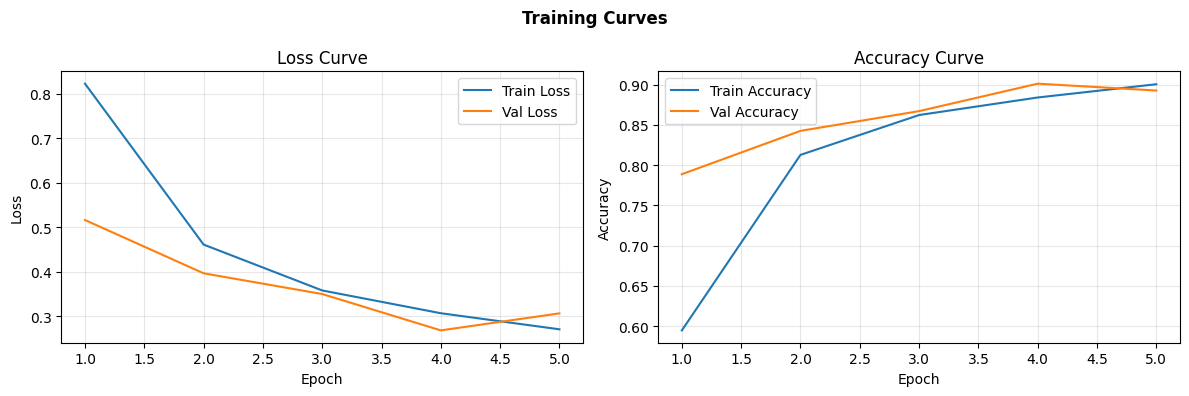

In [12]:
plot_training_curves(train_losses, val_losses, train_accs, val_accs)

The model hits **90.1% validation accuracy** in just 5 epochs, which is a strong baseline. Training accuracy for that epoch is **88.4%**, so there's no sign of overfitting yet

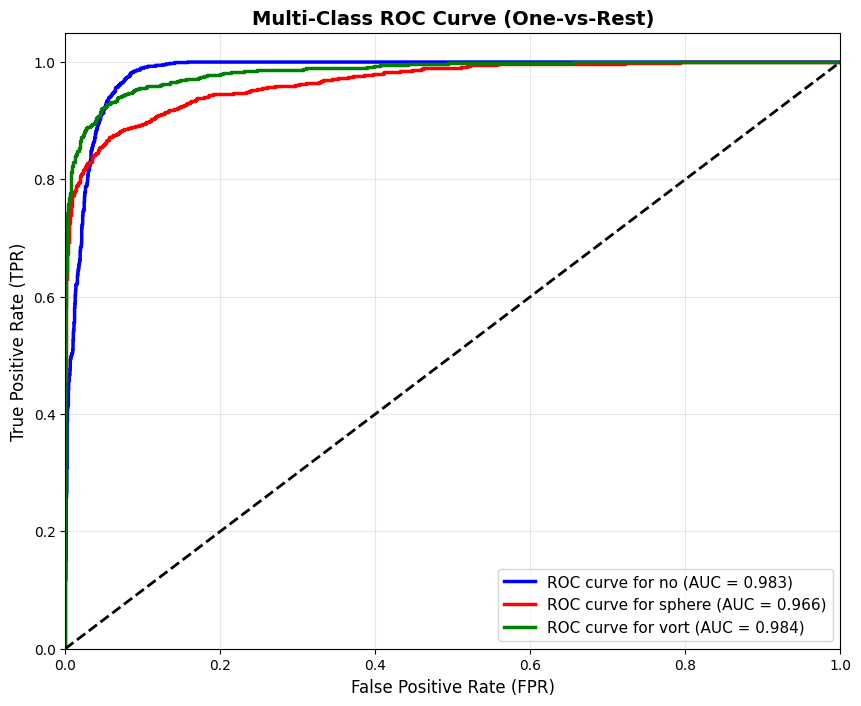

In [13]:
plot_roc(best_labels, best_probs, class_names=['no', 'sphere', 'vort'])

Since the accuracy was increasing I decided to give the model a few more runs to see the trend of accuracy further to see if we hit a ceiling or not.

In [14]:
model, best_labels, best_preds, best_probs, train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

Epoch 1/5



train: 100%|██████████| 1055/1055 [02:06<00:00,  8.33it/s]


train Loss: 0.273 Acc: 0.897


val: 100%|██████████| 118/118 [00:05<00:00, 21.62it/s]


val Loss: 0.293 Acc: 0.898

Epoch 2/5



...

val Loss: 0.236 Acc: 0.911

Epoch 5/5



train: 100%|██████████| 1055/1055 [02:05<00:00,  8.39it/s]


train Loss: 0.192 Acc: 0.931


val: 100%|██████████| 118/118 [00:05<00:00, 20.53it/s]


val Loss: 0.204 Acc: 0.924

Best Validation Accuracy: 0.924000


The train/val gap is starting to open from epoch 7 onward. Training 
accuracy pulls ahead while val accuracy plateaus around 92%. Val loss 
also zig-zags rather than converging cleanly, which is the optimizer 
bouncing at a fixed learning rate. These two signals together motivate 
adding a scheduler in the next experiment.

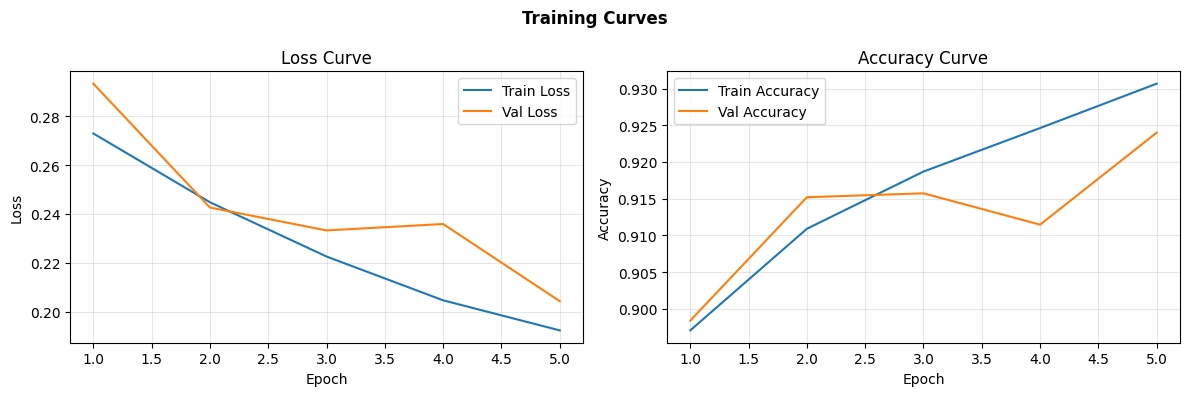

In [15]:
plot_training_curves(train_losses, val_losses, train_accs, val_accs)

### Result

Best val accuracy came out to **92.4%**. Still improving, but two problems are showing up:

The validation loss is zig-zagging instead of converging cleanly. This means the static `1e-4` is causing the optimizer to overshoot around the loss minimum. And the train/val gap is starting to open slightly, which is early memorization creep.

Flips-only augmentation might also be hitting a ceiling since the training distribution might not be diverse enough to push further. For the next experiment I will add a scheduler and heavier augmentations to address both.

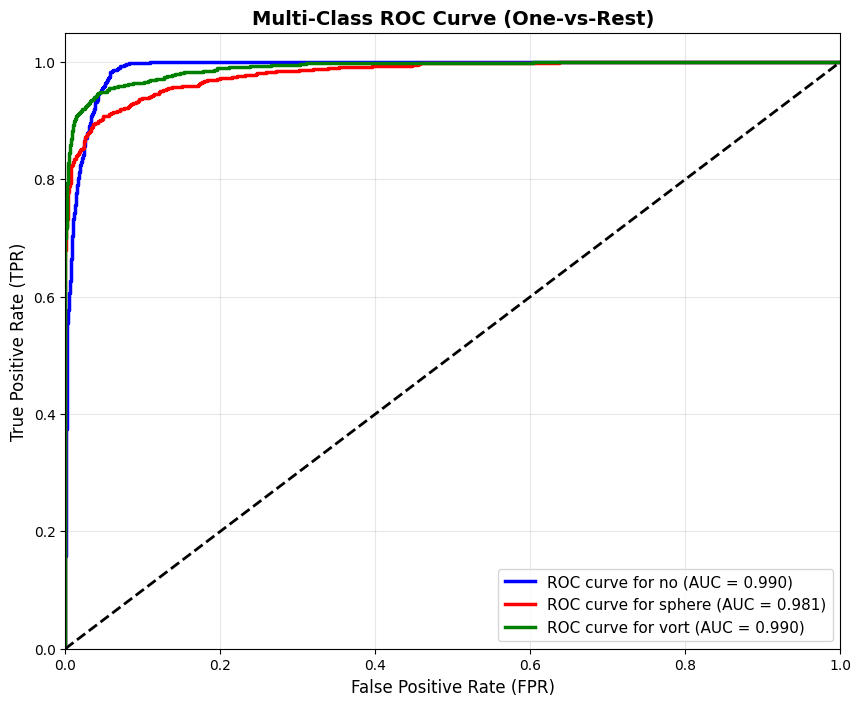

In [16]:
plot_roc(best_labels, best_probs, class_names=['no', 'sphere', 'vort'])

---

## Experiment 2: Heavy Augmentations + Scheduler

Same ResNet-18 and AdamW with two changes:

`RandomRotation(180)` and `ColorJitter(brightness=0.2, contrast=0.2)` added on top of the flips. Rotation up to 180° is physically justified for lensing images. ColorJitter adds some robustness to intensity variations.

`ReduceLROnPlateau` scheduler (factor=0.5, patience=3). If val loss doesn't improve for 3 epochs, learning rate gets halved. Direct fix for the optimizer bounce in Experiment 1.

**Note:** I had tried to convert the numerical values to images using PIL before applying the Color augmentation but this became extremely expensive computationally. The training time shot up and the accuracy was also struggling to go up (most likely because numerical precision was lost). I decided to abort that run and remove the conversion.

In [17]:
# setting up different and more aggressive augmentations for our next experiment
new_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
])

train_loader_v2, val_loader_v2 = preparing(PATH, batch_size=32, train_transform=new_transforms)

# reset the model weights and optimizer for the new training with different augmentations
model_v2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_v2.fc = nn.Linear(model_v2.fc.in_features, 3)
model_v2 = model_v2.to(device)

optimizer_v2 = optim.AdamW(model_v2.parameters(), lr=1e-4, weight_decay=1e-4)

# using a lr scheduler that reduces the lr by a factor of 0.5 if the validation loss does not improve for 3 consecutive epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_v2, mode='min', factor=0.5, patience=3)

Running for more epochs (30) to give the scheduler time to kick in. Early epochs will look probably look worse than Experiment 1 because the harder augmentations mean harder training distribution.

In [18]:
model_v2, labels_v2, preds_v2, probs_v2, train_losses_v2, val_losses_v2, train_accs_v2, val_accs_v2 = train_model(model_v2, train_loader_v2, val_loader_v2, criterion, optimizer_v2, epochs=30, scheduler=scheduler)

Epoch 1/30



train: 100%|██████████| 1055/1055 [03:32<00:00,  4.96it/s]


train Loss: 0.977 Acc: 0.489


val: 100%|██████████| 118/118 [00:04<00:00, 24.13it/s]


val Loss: 0.709 Acc: 0.686

Epoch 2/30



...

val Loss: 0.169 Acc: 0.938

Epoch 30/30



train: 100%|██████████| 1055/1055 [03:40<00:00,  4.80it/s]


train Loss: 0.183 Acc: 0.934


val: 100%|██████████| 118/118 [00:04<00:00, 24.48it/s]

val Loss: 0.156 Acc: 0.942

Best Validation Accuracy: 0.942133


The effect of the harder augmentation is visible immediately: epoch 1 
train accuracy is only 48.9% compared to 59.5% in Experiment 1 at the 
same point. The model is learning from a harder distribution. Val 
accuracy consistently exceeds train accuracy through the middle epochs 
(e.g. epoch 23: train 91.2%, val 93.1%) because the val set sees clean 
unaugmented images while training sees rotated, jittered versions. The 
scheduler starts around epoch 20 when val loss plateaus, which produces 
the jump from 92.7% to 94.2% in the final epochs.

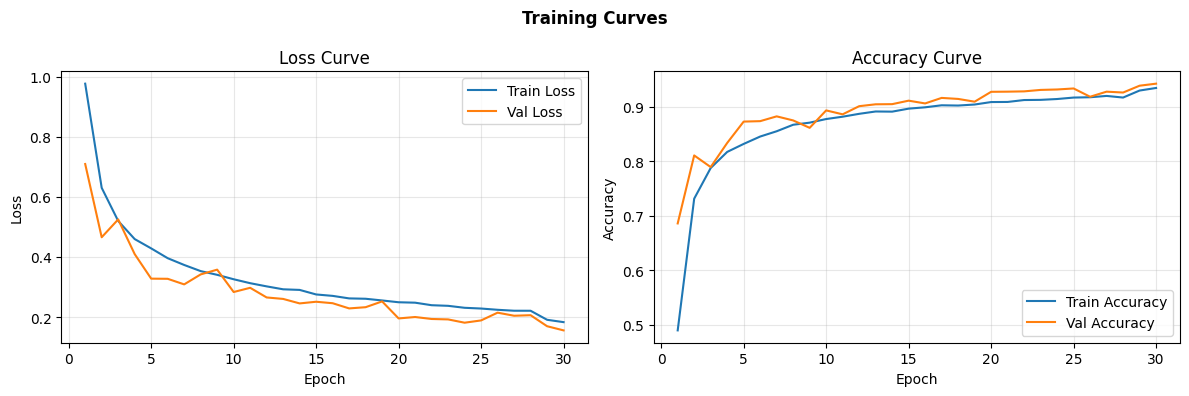

In [19]:
plot_training_curves(train_losses_v2, val_losses_v2, train_accs_v2, val_accs_v2)

### Results

**94.2% val accuracy** a meaningful jump from 92.4%.

A few things worth noting in the curves: validation accuracy actually exceeds training accuracy through the middle epochs (e.g. epoch 23: train 91.2%, val 93.1%). That's because the training set is harder than the clean val set, so the model has to learn the actual signal rather than memorizing orientations.

The cost is time. ~3:20 per epoch vs ~1:55 is nearly double.

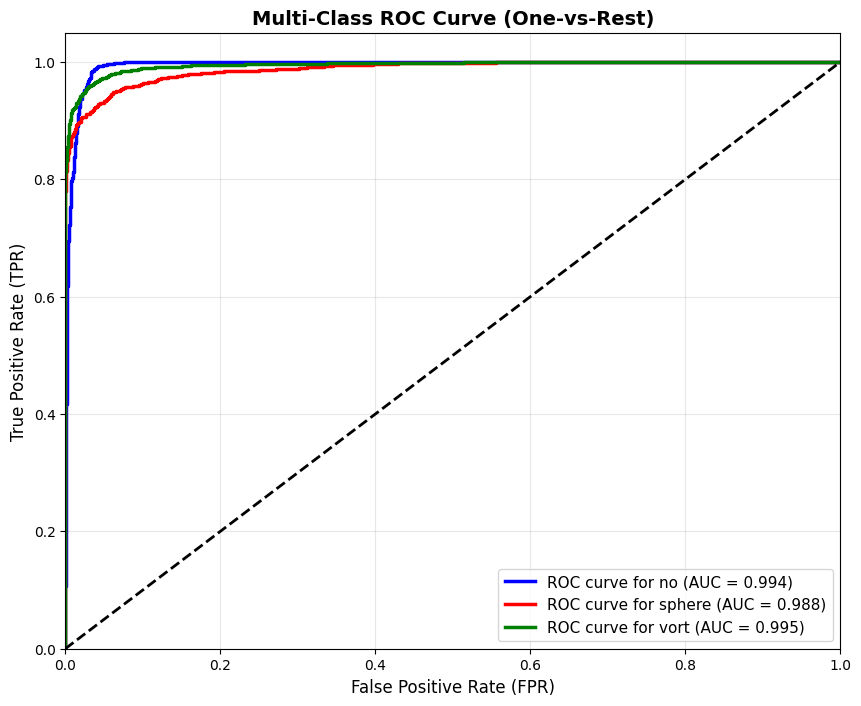

In [20]:
plot_roc(labels_v2, probs_v2, class_names=['no', 'sphere', 'vort'])

---

## Experiment 3: Flips Only + Scheduler (Final Model)

Back to flip-only augmentations, but now with the `ReduceLROnPlateau` scheduler from Experiment 2. This experiment was done by me out of curiosity only. I wanted to see what will be the effect if I put a scheduler without the aggressive augmentations.

In [21]:
# using old transforms to see the effect of just training for more epochs without changing the augmentations and adding the scheduler
train_loader_v3, val_loader_v3 = preparing(PATH, batch_size=32)

# reset the model weights and optimizer for the new training with different augmentations
model_v3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_v3.fc = nn.Linear(model_v3.fc.in_features, 3)
model_v3 = model_v3.to(device)

# same optimizer and scheduler as the previous experiment
optimizer_v3 = optim.AdamW(model_v3.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_v3, mode='min', factor=0.5, patience=3)

In [22]:
model_v3, labels_v3, preds_v3, probs_v3, train_losses_v3, val_losses_v3, train_accs_v3, val_accs_v3 = train_model(model_v3, train_loader_v3, val_loader_v3, criterion, optimizer_v3, epochs=25, scheduler=scheduler)

Epoch 1/25



train: 100%|██████████| 1055/1055 [02:08<00:00,  8.20it/s]


train Loss: 0.835 Acc: 0.589


val: 100%|██████████| 118/118 [00:05<00:00, 22.97it/s]


val Loss: 0.547 Acc: 0.771

Epoch 2/25



...

val Loss: 0.131 Acc: 0.957

Epoch 25/25



train: 100%|██████████| 1055/1055 [02:00<00:00,  8.76it/s]


train Loss: 0.047 Acc: 0.984


val: 100%|██████████| 118/118 [00:05<00:00, 21.73it/s]

val Loss: 0.138 Acc: 0.954

Best Validation Accuracy: 0.957067


Train and 
val loss converge together smoothly through epoch 14, then the scheduler 
fires and both drop sharply, val loss falls from 0.190 to 0.131 between 
epochs 13 and 24. The train/val gap widens from epoch 22 onward as train 
accuracy pushes past 97% while val accuracy plateaus around 95–96%, 
which is early memorization starting. The simpler augmentation gave the model a cleaner gradient 
signal and the scheduler handled the convergence. This combination 
outperformed both previous experiments in less wall-clock time.

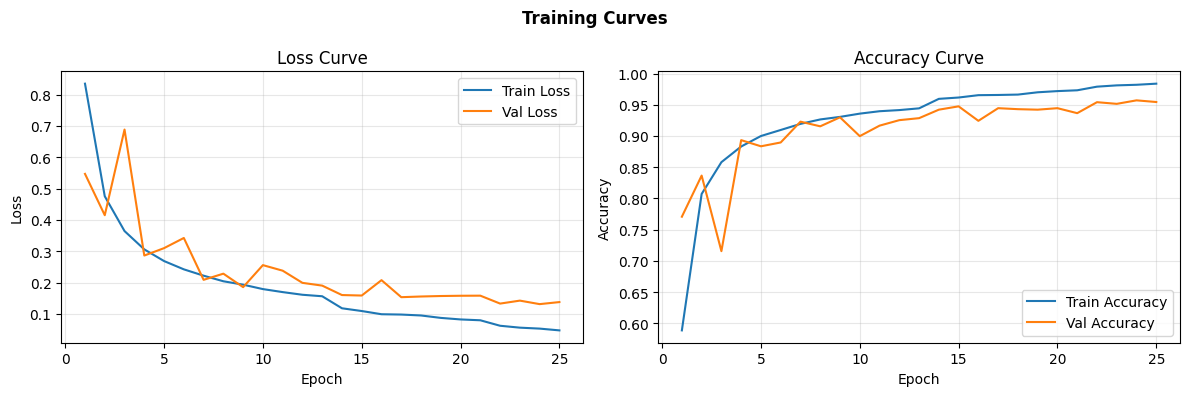

In [23]:
plot_training_curves(train_losses_v3, val_losses_v3, train_accs_v3, val_accs_v3)

### Results

**95.7% val accuracy** best across all three experiments.

The scheduler was doing the work all along. Simpler augmentations give the model a cleaner gradient signal, and once the learning rate is managed properly that's enough. The rotations in Experiment 2 were adding difficulty without proportional benefit.

### ROC for Final Model

Vortex is basically perfect (AUC 0.998), the ring/spiral pattern is visually distinct enough that the model separates it cleanly from both other classes. Most of the remaining error is between `no` and `sphere`, which makes sense: both are smooth blob-like structures with subtle radial intensity differences. The confusion matrix confirms this.

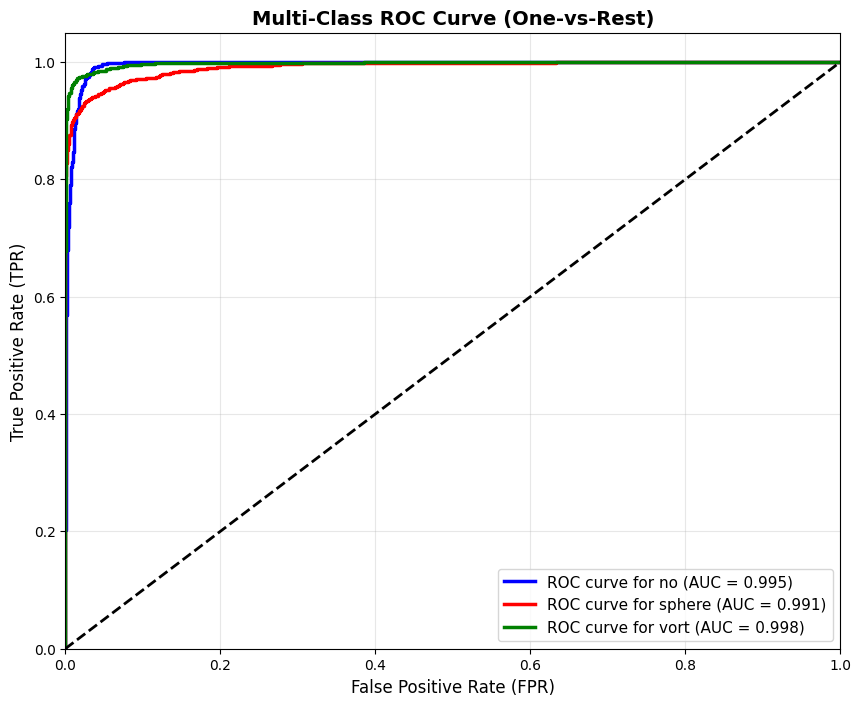

In [24]:
plot_roc(labels_v3, probs_v3, class_names=['no', 'sphere', 'vort'])

### Confusion Matrix

`no` is actually the cleanest class with only 34 total errors (97.3%), followed closely by `vort` at 44 errors (96.5%). `sphere` is the weakest at 83 errors (93.4%). It bleeds into both other classes, with 59 sphere samples called no and 24 called vort. The AUC is higher for vort because the model is extremely confident most of the times when it predicts vortex even if a few more got misclassified.

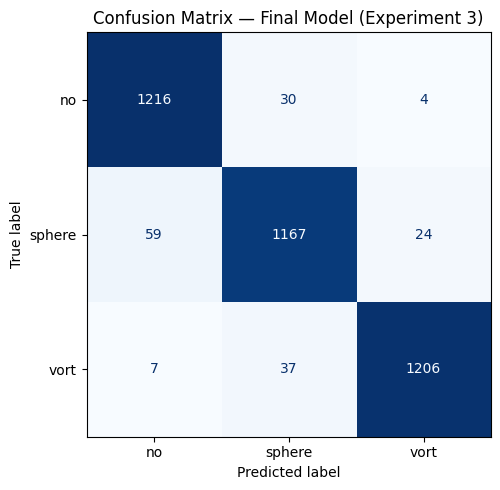

In [25]:
confusion_matrix_plot(labels_v3, preds_v3)

---

## Summary

| Experiment | Augmentations | Scheduler | Epochs | Best Val Acc |
|---|---|---|---|---|
| 1 (baseline) | Flips only | None | 10 | 92.4% |
| 2 | Flips + Rotation + ColorJitter | ReduceLROnPlateau | 30 | 94.2% |
| 3 (final) | Flips only | ReduceLROnPlateau | 25 | **95.7%** |

The scheduler mattered more than the augmentation strategy. Heavy augmentations help with generalization but the compute cost was real, and the simpler setup with a well-tuned scheduler got further.